# DSS5201 Group Project: Coffee Consumption, Preferences, and Spending

**Group Name:** Replace with your group name  
**Members:** Replace with member names and student IDs  
**Topic:** The Great American Coffee Taste Test (TidyTuesday 2024-05-14)

**Research question:** What demographic, taste-preference, and self-rated expertise factors are associated with higher coffee spending among respondents in the Great American Coffee Taste Test survey?

## 1. Introduction

This project analyses the `coffee_survey.csv` data set released through TidyTuesday on 14 May 2024, originally collected during **The Great American Coffee Taste Test** — a large-scale online tasting event organised by James Hoffmann and Cometeer in October 2023 (Hoffmann, 2023). Roughly 4,000 participants across the United States brewed four blind-labelled coffees at home while following a YouTube livestream, then completed a survey covering demographics, daily coffee habits, brewing equipment, flavour preferences, self-rated expertise, and spending behaviour. The resulting data set contains 4,042 responses and 57 variables. An early exploratory analysis by McKeon Aloe (2023) documented the broad demographic profile of the respondents — predominantly young, male, and inclined toward light roasts — while the Maven Analytics Coffee Challenge (2024) invited analysts to derive actionable market-entry recommendations from the same data.

Building on these prior explorations, we focus specifically on **what demographic, behavioural, and attitudinal factors are associated with higher coffee spending**. We decompose this overarching question into three sub-questions, each targeting a distinct driver category:

1. **Demographics** — How do age and education level relate to monthly coffee expenditure?
2. **Brewing and taste preferences** — Which home-brewing method and favourite-drink combinations are associated with higher spending?
3. **Self-rated expertise** — Does higher expertise predict greater investment in equipment, in monthly spending, or both?

Each sub-question is addressed with a dedicated visualisation (grouped bar chart, heatmap, and line chart, respectively), using a largely non-overlapping set of variables. Because the sample is self-selected and drawn from a YouTube-based tasting event, it likely over-represents coffee enthusiasts relative to the general population. All findings should therefore be interpreted as descriptive associations within this convenience sample rather than causal effects or nationally representative estimates.

In [6]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# ── Polished visual theme ────────────────────────────────────────────
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#999999",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.5,
    "legend.fontsize": 10,
    "legend.frameon": False,
})

SOURCE_LINE = "Source: The Great American Coffee Taste Test (TidyTuesday, 2024-05-14)"

# ── Data loading ─────────────────────────────────────────────────────
ROOT = Path.cwd()
LOCAL_DATA_PATH = ROOT / "data" / "coffee_survey.csv"
DATA_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv"

if LOCAL_DATA_PATH.exists():
    raw = pd.read_csv(LOCAL_DATA_PATH)
    data_source = str(LOCAL_DATA_PATH)
else:
    raw = pd.read_csv(DATA_URL)
    data_source = DATA_URL

print(f"Loaded {len(raw):,} rows and {raw.shape[1]} columns from: {data_source}")

Loaded 4,042 rows and 57 columns from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv


## 2. Data Cleaning and Summary

We retained only the variables needed for our three research questions: `age`, `education_level`, `total_spend`, `brew`, `favorite`, `expertise`, and `spent_equipment`. Education levels were collapsed into three groups — High school or below, Bachelor's, and Graduate or above — to keep group sizes large enough for meaningful comparison. Monthly spending brackets were converted to approximate numeric midpoints (e.g., the 20–40 dollar range becomes 30) so that average spending can be displayed on a continuous scale. Because `brew` is a multi-select question, respondents can contribute to more than one brewing category in Figure 2; this figure should therefore be read as overlapping user profiles rather than mutually exclusive groups. We limited the display to the five most common brewing methods and the five most common favorite drinks. For Figure 3, `spent_equipment` and `total_spend` were converted into binary "high" indicators (equipment spending of 500 dollars or more, monthly spending of 60 dollars or more) so that both metrics can be plotted on a common percentage scale.

Missing values are handled separately for each figure to maximize the analytic sample in each case.

In [7]:
# ── Shared constants ──────────────────────────────────────────────────
spend_order = ["<$20", "$20-$40", "$40-$60", "$60-$80", "$80-$100", ">$100"]

spend_midpoints = {
    "<$20": 10, "$20-$40": 30, "$40-$60": 50,
    "$60-$80": 70, "$80-$100": 90, ">$100": 120,
}

edu_map = {
    "Less than high school": "≤ High school",
    "High school graduate": "≤ High school",
    "Some college or associate's degree": "≤ High school",
    "Bachelor's degree": "Bachelor's",
    "Master's degree": "Graduate+",
    "Doctorate or professional degree": "Graduate+",
}

top_methods = [
    "Pour over", "Espresso", "French press",
    "Coffee brewing machine (e.g. Mr. Coffee)",
    "Pod/capsule machine (e.g. Keurig/Nespresso)",
]
method_labels = {
    "Pour over": "Pour over",
    "Espresso": "Espresso",
    "French press": "French press",
    "Coffee brewing machine (e.g. Mr. Coffee)": "Drip machine",
    "Pod/capsule machine (e.g. Keurig/Nespresso)": "Pod / capsule",
}

top_favorites = ["Pourover", "Espresso", "Cappuccino", "Latte", "Regular drip coffee"]
favorite_labels = {
    "Pourover": "Pour-over",
    "Espresso": "Espresso",
    "Cappuccino": "Cappuccino",
    "Latte": "Latte",
    "Regular drip coffee": "Drip coffee",
}

# ── Derived columns ──────────────────────────────────────────────────
coffee = raw.copy()

# Map spending to numeric BEFORE converting to Categorical
coffee["spend_numeric"] = coffee["total_spend"].map(spend_midpoints).astype(float)
coffee["total_spend"] = pd.Categorical(coffee["total_spend"], categories=spend_order, ordered=True)
coffee["high_spend"] = coffee["total_spend"].isin(["$60-$80", "$80-$100", ">$100"])

coffee["edu_group"] = pd.Categorical(
    coffee["education_level"].map(edu_map),
    categories=["≤ High school", "Bachelor's", "Graduate+"], ordered=True,
)
coffee["high_equip"] = coffee["spent_equipment"].isin(["$500-$1000", "More than $1,000"])

# Age — drop <18 (only ~13 responses)
age_order = [
    "18-24 years old", "25-34 years old", "35-44 years old",
    "45-54 years old", "55-64 years old", ">65 years old",
]
age_labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
coffee["age"] = pd.Categorical(coffee["age"], categories=age_order, ordered=True)

# ── Figure 1: grouped bar — % high spend by age × education ─────────
fig1_df = (
    coffee.dropna(subset=["age", "edu_group", "total_spend"])
    .loc[lambda d: d["age"].isin(age_order)]
    .copy()
)

# ── Figure 2: heatmap — brew × favorite → mean monthly spending ─────
brew_long = (
    coffee.loc[coffee["favorite"].isin(top_favorites)]
    .dropna(subset=["brew", "spend_numeric"])
    .assign(
        brew_list=lambda d: d["brew"].str.split(",").apply(
            lambda v: [x.strip() for x in v if x.strip()]
        )
    )
    .explode("brew_list")
    .loc[lambda d: d["brew_list"].isin(top_methods)]
    .assign(
        brew_display=lambda d: pd.Categorical(
            d["brew_list"].map(method_labels),
            categories=[method_labels[m] for m in top_methods], ordered=True,
        ),
        fav_display=lambda d: pd.Categorical(
            d["favorite"].map(favorite_labels),
            categories=[favorite_labels[f] for f in top_favorites], ordered=True,
        ),
    )
)
fig2_matrix = (
    brew_long.groupby(["brew_display", "fav_display"], observed=True)
    .agg(n=("spend_numeric", "count"), mean_spend=("spend_numeric", "mean"))
    .reset_index()
)

# ── Figure 3: line — expertise → % high equipment & % high monthly ──
fig3_df = coffee.dropna(subset=["expertise", "high_spend", "high_equip"]).copy()

# ── Summary tables ───────────────────────────────────────────────────
summary_table = pd.DataFrame({
    "Metric": [
        "Raw survey responses",
        "Raw variables",
        "Figure 1 analytic sample",
        "Figure 2 rows (after exploding brew)",
        "Figure 3 analytic sample",
    ],
    "Value": [
        f"{len(raw):,}",
        raw.shape[1],
        f"{len(fig1_df):,}",
        f"{len(brew_long):,}",
        f"{len(fig3_df):,}",
    ],
})

missingness = (
    raw[["age", "education_level", "total_spend", "brew", "favorite",
         "expertise", "spent_equipment"]]
    .isna().mean().mul(100).round(1)
    .rename("Missing %").to_frame()
)

display(summary_table)
display(missingness)

,Metric,Value
0,Raw survey responses,"4,042"
1,Raw variables,57
2,Figure 1 analytic sample,"3,373"
3,Figure 2 rows (after exploding brew),"3,698"
4,Figure 3 analytic sample,"3,938"


,Missing %
age,0.8
education_level,14.9
total_spend,13.1
brew,9.5
favorite,1.5
expertise,2.6
spent_equipment,13.3


The summary tables indicate that missingness is modest for most analytical variables: age (0.8%), brew (9.5%), favorite (1.5%), and expertise (2.6%) each have fewer than 10% missing values, while education level, total spending, and equipment spending are each missing for roughly 13–15% of respondents. Because the three figures draw on different subsets of variables, we handle missing data separately for each figure, retaining the largest possible analytic sample in each case rather than restricting all analyses to a single complete-case subset.

## 3. Visualization

### Figure 1. How do age and education level relate to monthly coffee spending?

This figure uses `age`, `education_level`, and `total_spend`. A grouped bar chart showing the percentage of high spenders (60 dollars or more per month) is the most direct way to compare the two dimensions: age groups sit along the x-axis, while three education-level bars at each position allow immediate side-by-side comparison. This design reduces clutter compared to a faceted stacked bar and focuses the reader's attention on the single metric that matters most — the share of high spenders.

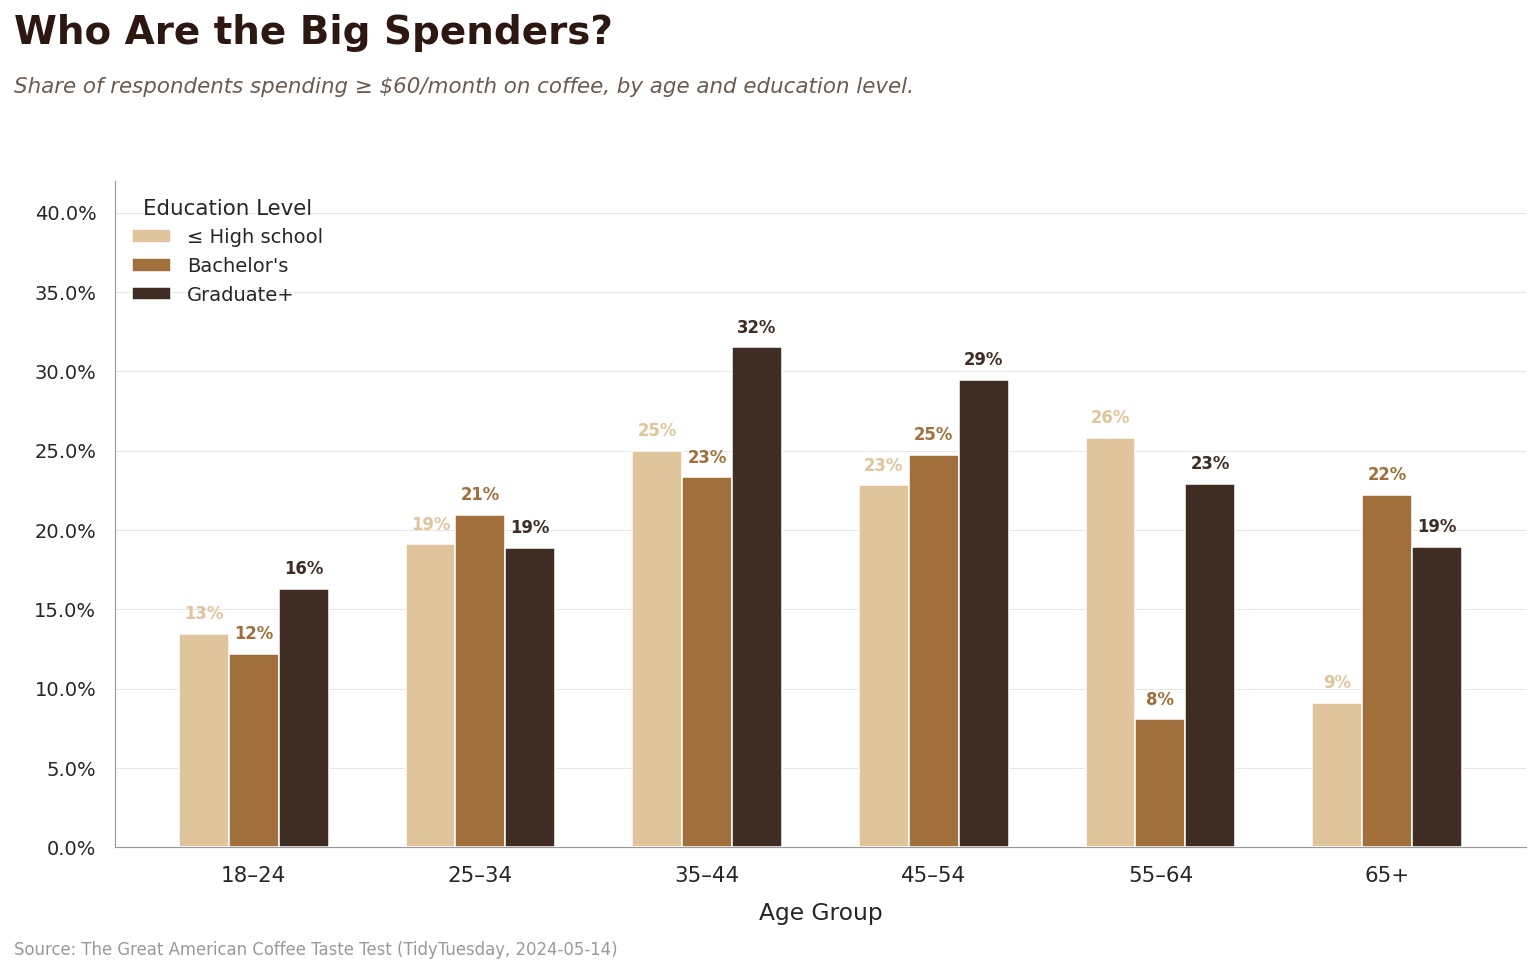

In [8]:
# ── Figure 1: Grouped Bar — % high spenders by Age × Education ───────
edu_cats = ["≤ High school", "Bachelor's", "Graduate+"]
edu_colors = ["#dfc49c", "#a06f3b", "#3f2c23"]

bar_data = (
    fig1_df.groupby(["age", "edu_group"], observed=True)["high_spend"]
    .agg(["mean", "count"])
    .reset_index()
    .query("count >= 10")
)

fig, ax = plt.subplots(figsize=(12, 7))
fig.subplots_adjust(top=0.82, bottom=0.14, left=0.08, right=0.92)

n_ages = len(age_order)
bar_width = 0.22
x_base = np.arange(n_ages)

for i, (edu, color) in enumerate(zip(edu_cats, edu_colors)):
    sub = bar_data[bar_data["edu_group"] == edu].set_index("age")
    heights = [sub.loc[a, "mean"] if a in sub.index else 0 for a in age_order]
    counts = [int(sub.loc[a, "count"]) if a in sub.index else 0 for a in age_order]
    x_pos = x_base + (i - 1) * bar_width

    bars = ax.bar(
        x_pos, heights, width=bar_width, color=color,
        edgecolor="white", linewidth=0.8, label=edu, zorder=3,
    )
    for bar_obj, h, n in zip(bars, heights, counts):
        if h > 0:
            ax.text(
                bar_obj.get_x() + bar_obj.get_width() / 2, h + 0.007,
                f"{h:.0%}", ha="center", va="bottom", fontsize=8.5,
                color=color, fontweight="bold",
            )

ax.set_xticks(x_base)
ax.set_xticklabels(age_labels, fontsize=11)
ax.set_xlabel("Age Group", fontsize=12, labelpad=8)
ax.set_ylabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 0.42)
ax.yaxis.grid(True, linewidth=0.4, color="#e0e0e0")
ax.set_axisbelow(True)
ax.legend(title="Education Level", loc="upper left", fontsize=10, title_fontsize=11)

fig.text(0.02, 0.96, "Who Are the Big Spenders?",
         fontsize=20, fontweight="bold", color="#2c1810")
fig.text(0.02, 0.91,
         "Share of respondents spending \u2265 \u002460/month on coffee, by age and education level.",
         fontsize=11, fontstyle="italic", color="#6b5b4f")
fig.text(0.02, 0.03, SOURCE_LINE, fontsize=8.5, color="#999999")
plt.show()

### Figure 2. Which brewing-method and favorite-drink combinations are associated with higher spending?

This figure uses `brew`, `favorite`, and `total_spend` (converted to numeric midpoints). A heatmap is ideal here because two categorical dimensions — 5 brewing methods and 5 favorite drinks — naturally form a 5 × 5 matrix, and color intensity directly encodes average monthly spending. Each cell is annotated with the dollar amount and respondent count. Because `brew` is multi-select, a respondent may appear in more than one row; the figure should therefore be read as overlapping profiles rather than mutually exclusive groups.

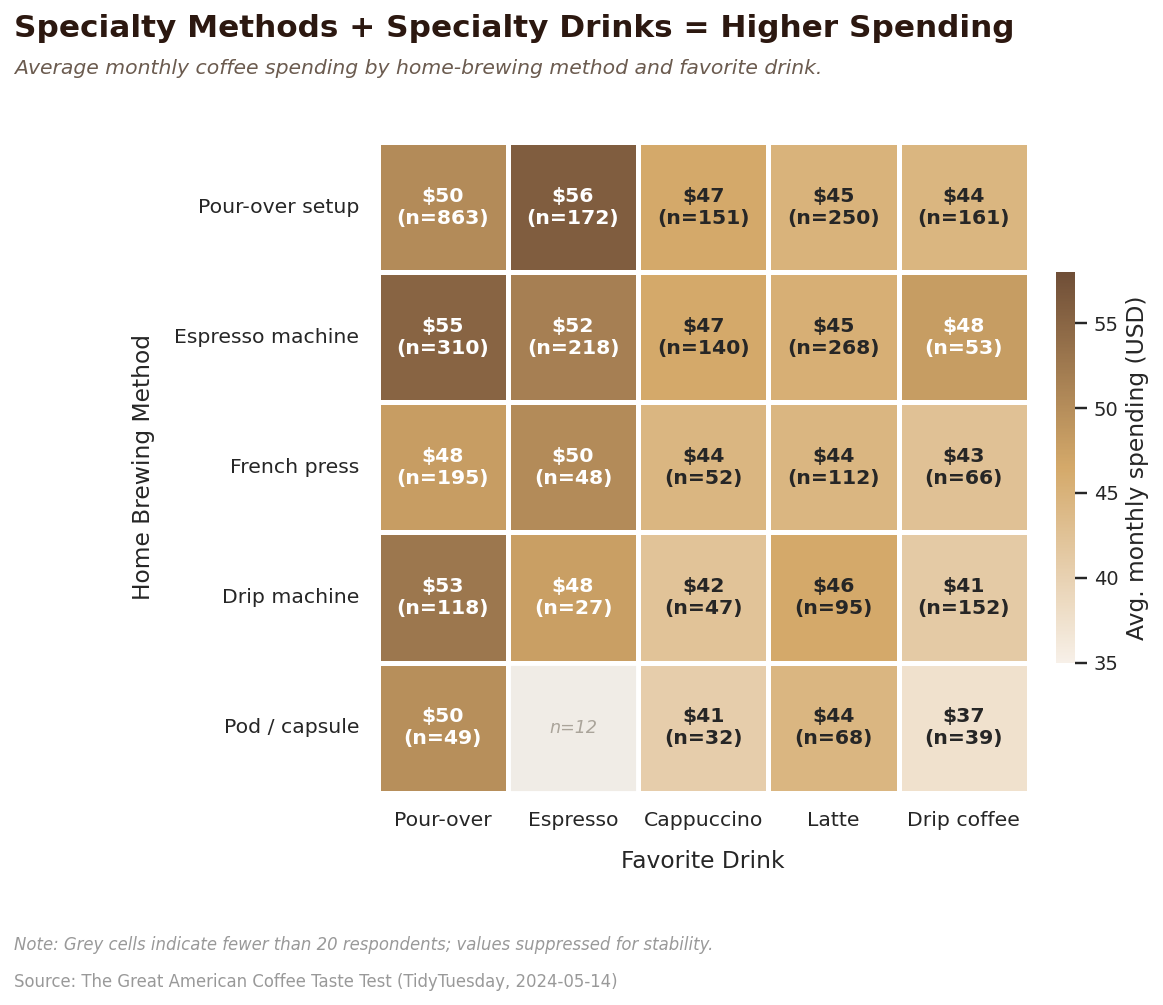

In [9]:
# ── Figure 2: Heatmap — brew × favorite → mean monthly spending ──────
brew_order = [method_labels[m] for m in top_methods]
fav_order = [favorite_labels[f] for f in top_favorites]

spend_mat = fig2_matrix.pivot(index="brew_display", columns="fav_display", values="mean_spend")
spend_mat = spend_mat.reindex(index=brew_order, columns=fav_order)

count_mat = fig2_matrix.pivot(index="brew_display", columns="fav_display", values="n")
count_mat = count_mat.reindex(index=brew_order, columns=fav_order).fillna(0)

mask = count_mat < 20

# Annotation: "$XX\n(n=123)"
annot = pd.DataFrame("", index=spend_mat.index, columns=spend_mat.columns)
for row in spend_mat.index:
    for col in spend_mat.columns:
        n = count_mat.loc[row, col]
        v = spend_mat.loc[row, col]
        if n >= 20 and pd.notna(v):
            annot.loc[row, col] = f"${v:.0f}\n(n={int(n)})"

heatmap_cmap = sns.blend_palette(["#f7f0e8", "#d4a96a", "#6f4e37"], as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.subplots_adjust(top=0.84, bottom=0.22, left=0.22, right=0.86)

sns.heatmap(
    spend_mat.where(~mask), ax=ax, cmap=heatmap_cmap,
    annot=annot, fmt="", linewidths=2.5, linecolor="white",
    vmin=35, vmax=58, square=True,
    cbar_kws={"label": "Avg. monthly spending (USD)", "shrink": 0.6, "pad": 0.03},
    annot_kws={"fontsize": 10.5, "fontweight": "bold"},
)

# Grey out small-n cells
for i, row in enumerate(spend_mat.index):
    for j, col in enumerate(spend_mat.columns):
        if mask.loc[row, col]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                         facecolor="#f0ece6", edgecolor="white", linewidth=2.5))
            n_val = int(count_mat.loc[row, col])
            label = f"n={n_val}" if n_val > 0 else "\u2014"
            ax.text(j + 0.5, i + 0.5, label,
                    ha="center", va="center", fontsize=9, color="#aaa49a", fontstyle="italic")

# Differentiated axis labels — NO emoji, clear distinction
brew_display_labels = [
    "Pour-over setup", "Espresso machine", "French press", "Drip machine", "Pod / capsule"
]
fav_display_labels = ["Pour-over", "Espresso", "Cappuccino", "Latte", "Drip coffee"]

ax.set_xlabel("Favorite Drink", fontsize=12, labelpad=10)
ax.set_ylabel("Home Brewing Method", fontsize=12, labelpad=10)
ax.set_xticklabels(fav_display_labels, rotation=0, ha="center", fontsize=10.5)
ax.set_yticklabels(brew_display_labels, rotation=0, fontsize=10.5)

# Titles aligned to figure left edge (0.02)
fig.text(0.02, 0.94,
         "Specialty Methods + Specialty Drinks = Higher Spending",
         fontsize=16, fontweight="bold", color="#2c1810")
fig.text(0.02, 0.905,
         "Average monthly coffee spending by home-brewing method and favorite drink.",
         fontsize=10.5, fontstyle="italic", color="#6b5b4f")

# Note + source at bottom with clear spacing
fig.text(0.02, 0.07,
         "Note: Grey cells indicate fewer than 20 respondents; values suppressed for stability.",
         fontsize=8.5, fontstyle="italic", color="#999999")
fig.text(0.02, 0.035, SOURCE_LINE, fontsize=8.5, color="#999999")
plt.show()

### Figure 3. Do self-rated coffee experts spend more on equipment and on monthly coffee?

This figure uses `expertise`, `spent_equipment`, and `total_spend`. A line chart is ideal here because expertise is measured on a 1–10 scale, and lines reveal the trend across the full range. Two metrics are plotted on the same percentage axis — the share of respondents who invested 500 dollars or more in equipment and the share who spend 60 dollars or more per month on coffee — so we can compare how steeply each rises with expertise. Shaded bands show ±1 standard error to indicate the precision of each point estimate.

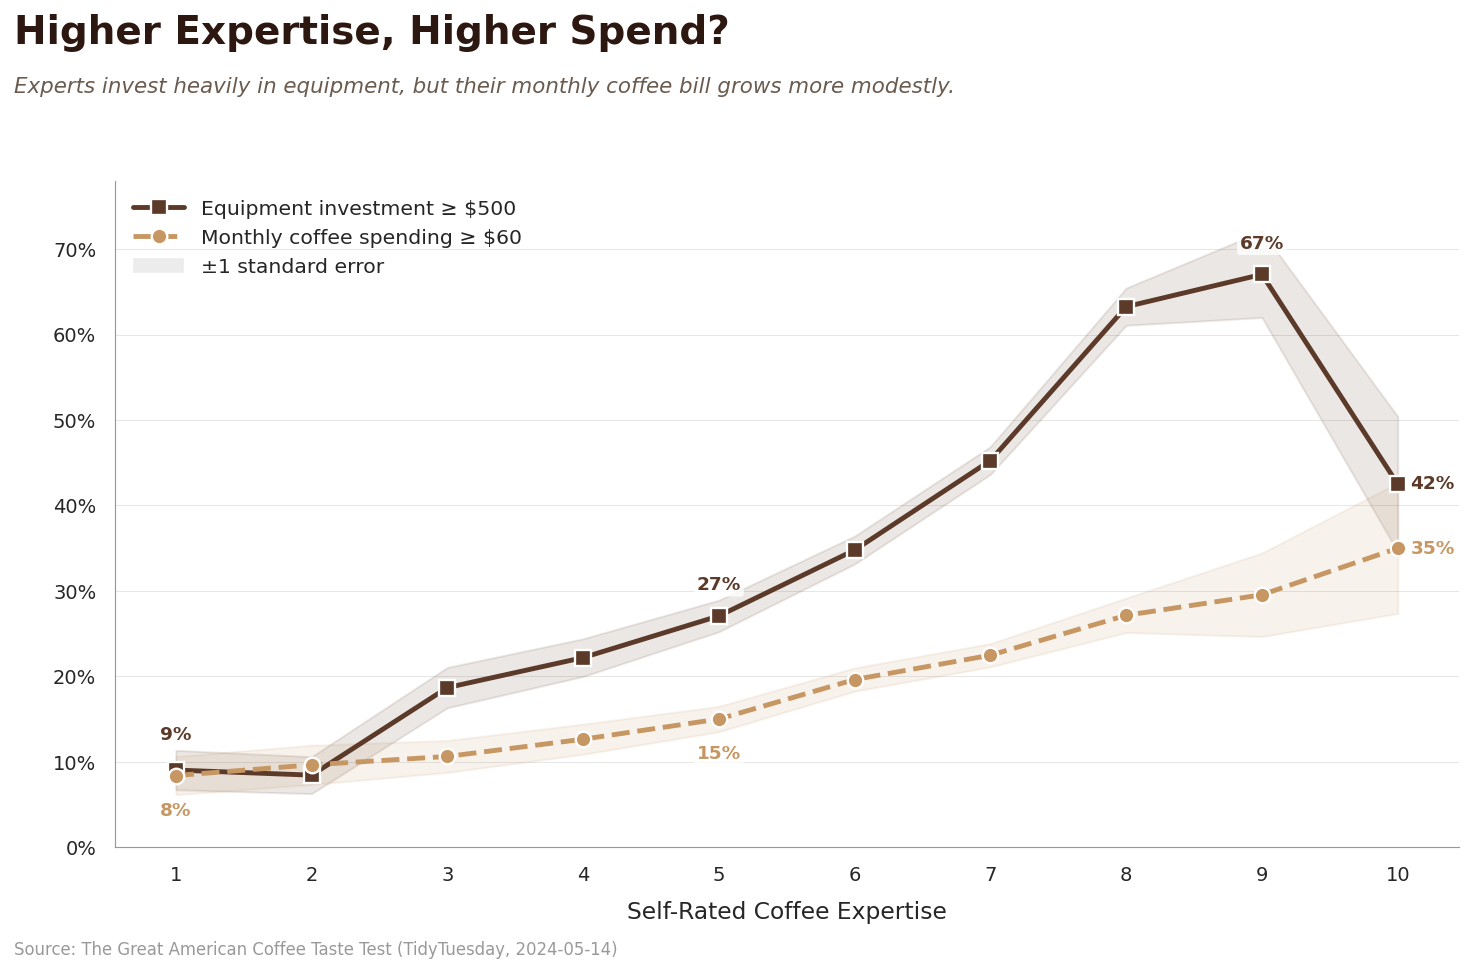

In [10]:
# ── Figure 3: Line Chart — expertise → % high equipment & % high monthly ─
fig, ax = plt.subplots(figsize=(12, 7))
fig.subplots_adjust(top=0.82, bottom=0.14, left=0.08, right=0.88)

lines_cfg = [
    ("high_equip", "Equipment investment \u2265 \u0024500", "#5b3a29", "s", "-"),
    ("high_spend", "Monthly coffee spending \u2265 \u002460", "#c79763", "o", "--"),
]

all_stats = {}
for col, label, color, marker, ls in lines_cfg:
    stats = (
        fig3_df.groupby("expertise")[col]
        .agg(["mean", "sem", "count"])
        .reindex(range(1, 11))
    )
    stats = stats[stats["count"] >= 20]
    x = stats.index
    y = stats["mean"]
    se = stats["sem"]
    all_stats[col] = stats

    ax.plot(x, y, marker=marker, color=color, linewidth=2.5, linestyle=ls,
            markersize=8, markeredgecolor="white", markeredgewidth=1.2,
            label=label, zorder=4)
    ax.fill_between(x, y - se, y + se, color=color, alpha=0.12, zorder=2)

# Add a legend entry for the shaded SE band
from matplotlib.patches import Patch
se_patch = Patch(facecolor="#999999", alpha=0.18, label="\u00b11 standard error")

# ── Smart annotations with white background for readability ──────────
def annotate_pt(ax, txt, xy, ofs, color):
    ax.annotate(
        txt, xy, textcoords="offset points", xytext=ofs,
        fontsize=9.5, fontweight="bold", color=color,
        ha="center", va="center", zorder=6,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
    )

# Equipment line: start, mid, peak, last
eq = all_stats["high_equip"]["mean"]
peak_eq_x = eq.idxmax()
peak_eq_y = eq.loc[peak_eq_x]
annotate_pt(ax, f"{eq.iloc[0]:.0%}", (eq.index[0], eq.iloc[0]), (0, 18), "#5b3a29")
annotate_pt(ax, f"{eq.loc[5]:.0%}", (5, eq.loc[5]), (0, 16), "#5b3a29")
if peak_eq_x != eq.index[-1] and peak_eq_x != 5:
    annotate_pt(ax, f"{peak_eq_y:.0%}", (peak_eq_x, peak_eq_y), (0, 16), "#5b3a29")
annotate_pt(ax, f"{eq.iloc[-1]:.0%}", (eq.index[-1], eq.iloc[-1]), (18, 0), "#5b3a29")

# Monthly line: start, mid, peak, last
ms = all_stats["high_spend"]["mean"]
peak_ms_x = ms.idxmax()
peak_ms_y = ms.loc[peak_ms_x]
annotate_pt(ax, f"{ms.iloc[0]:.0%}", (ms.index[0], ms.iloc[0]), (0, -18), "#c79763")
annotate_pt(ax, f"{ms.loc[5]:.0%}", (5, ms.loc[5]), (0, -18), "#c79763")
if peak_ms_x != ms.index[-1] and peak_ms_x != 5:
    annotate_pt(ax, f"{peak_ms_y:.0%}", (peak_ms_x, peak_ms_y), (0, -18), "#c79763")
annotate_pt(ax, f"{ms.iloc[-1]:.0%}", (ms.index[-1], ms.iloc[-1]), (18, 0), "#c79763")

ax.set_xticks(range(1, 11))
ax.set_xlabel("Self-Rated Coffee Expertise", fontsize=12, labelpad=8)
ax.set_ylabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 0.78)
ax.yaxis.grid(True, linewidth=0.4, color="#e0e0e0")
ax.set_axisbelow(True)

# Legend with SE band entry
handles, labels = ax.get_legend_handles_labels()
handles.append(se_patch)
labels.append("\u00b11 standard error")
ax.legend(handles=handles, labels=labels, loc="upper left", fontsize=10.5, handlelength=2.5)

fig.text(0.02, 0.96, "Higher Expertise, Higher Spend?",
         fontsize=20, fontweight="bold", color="#2c1810")
fig.text(0.02, 0.91,
         "Experts invest heavily in equipment, but their monthly coffee bill grows more modestly.",
         fontsize=11, fontstyle="italic", color="#6b5b4f")
fig.text(0.02, 0.03, SOURCE_LINE, fontsize=8.5, color="#999999")
plt.show()

## 4. Discussion

**Figure 1.** The grouped bar chart indicates that both age and education are associated with the prevalence of high monthly coffee spending. Among respondents holding a graduate degree, the proportion spending 60 dollars or more per month peaks in the 35–44 age band (approximately 32%), exceeding the corresponding figures for the Bachelor's group (23%) and the high-school-or-below group (25%). At younger ages (18–24), the education gap is narrow, suggesting that the income advantage conferred by higher education translates into elevated discretionary spending primarily during the peak earning years. This is consistent with McKeon Aloe's (2023) observation that the survey sample skews young and educated, making income-related variation especially relevant for segmentation.

**Figure 2.** The heatmap reveals a pronounced spending gradient across the 5 x 5 matrix of brewing methods and favourite drinks. Respondents who brew with a pour-over setup or espresso machine and whose favourite drink is espresso or pour-over coffee report average monthly spending in the range of 50–56 dollars — the highest in the matrix. By contrast, pod/capsule and drip-machine users who favour regular drip coffee average 37–41 dollars. The approximately 19-dollar gap between the highest- and lowest-spending cells suggests that method–drink alignment is a meaningful marker of engagement with specialty coffee culture. An interesting asymmetry also emerges: respondents who use a drip machine yet favour pour-over coffee (53 dollars) spend more than espresso-machine owners who prefer lattes (45 dollars), implying that drink preference is at least as predictive of spending as equipment ownership alone.

**Figure 3.** The line chart demonstrates that self-rated expertise is positively associated with both equipment investment and monthly coffee spending, but the two relationships differ markedly in slope. The share of respondents reporting equipment expenditure of 500 dollars or more rises steeply from roughly 9% at expertise level 1 to over 60% at levels 8–9, whereas the share spending 60 dollars or more per month increases more gradually from about 8% to 30% over the same range. The widening gap between the two curves suggests that expertise manifests primarily as one-time capital investment in brewing equipment (grinders, espresso machines, pour-over gear) rather than as proportionally higher recurring expenditure on coffee itself.

**Synthesis.** Taken together, the three figures suggest that coffee spending in this sample is driven by complementary factors operating along distinct pathways. **Demographics** establish a baseline capacity to spend (age and education as proxies for disposable income). **Brewing and taste preferences** signal the depth of engagement with specialty coffee culture, which amplifies spending beyond what demographics alone would predict. **Self-rated expertise** channels spending toward durable equipment investment rather than day-to-day consumption. These three pathways — income, lifestyle, and identity — converge to shape total coffee expenditure, echoing the Maven Analytics Coffee Challenge's (2024) conclusion that specialty-oriented consumers represent a distinct high-value segment. However, the cross-sectional and self-reported nature of the data precludes causal interpretation, and the self-selected sample warrants caution when generalising to the broader U.S. coffee-drinking population.

## 5. Teamwork

Replace the placeholders below with your group's actual names and contributions before submission. A concise paragraph like the one below matches the assignment requirement:

*Our group divided the project across four workstreams. Member A refined the research question and drafted the introduction. Member B cleaned the data, created the derived variables, and checked missing values. Member C designed the visualizations and helped interpret the main patterns. Member D integrated the notebook, edited the discussion, and verified that the final notebook reproduced the same results as the HTML output. All members reviewed the final write-up and agreed on the final submission.*


## 6. References

1. Hoffmann, J. (2023, October 21). *The Great American Coffee Taste Test* [Video]. YouTube. https://www.youtube.com/watch?v=bMOOQfeloH0
2. Cometeer. (2023). *The Great American Coffee Taste Test*. https://cometeer.com/pages/the-great-american-coffee-taste-test
3. TidyTuesday. (2024, May 14). *The Great American Coffee Taste Test* [Data set]. R for Data Science Online Learning Community. https://github.com/rfordatascience/tidytuesday/tree/main/data/2024/2024-05-14
4. McKeon Aloe, R. (2023, November). Great American Coffee Taste Test breakdown. *Medium*. https://rmckeon.medium.com/great-american-coffee-taste-test-breakdown-7f3fdcc3c41d
5. Maven Analytics. (2024). *Maven Coffee Challenge*. https://mavenanalytics.io/challenges/maven-coffee-challenge
6. Dahiya, A. (2024, May 15). The Great American Coffee Taste Test [TidyTuesday visualisation]. *Data Viz Collective*. https://aditya-dahiya.github.io/projects_presentations/data_vizs/tidy_coffee_test.html